# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [74]:
df = pd.read_csv("checker_submits.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   uid        1686 non-null   object        
 1   labname    1686 non-null   object        
 2   numTrials  1686 non-null   int64         
 3   timestamp  1686 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 52.8+ KB


In [75]:
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.day_of_week
df.drop('timestamp', axis=1, inplace=True)
df.sample(5)

,uid,labname,numTrials,hour,dayofweek
34,user_12,laba04,2,17,5
945,user_20,project1,7,16,0
487,user_8,laba05,5,13,5
1465,user_8,project1,6,17,3
658,user_4,project1,41,13,0


In [76]:
print("feature 1: ", df['uid'].nunique('sum'), "  to_encode")
print("feature 2: ", df['labname'].nunique('sum'), "  to_encode")
print("feature 3: ", df['numTrials'].nunique('sum'))
print("feature 4: ", df['hour'].nunique('sum'))
print("target:    ", df['dayofweek'].nunique('sum'))

feature 1:  30   to_encode
feature 2:  11   to_encode
feature 3:  164
feature 4:  22
target:     7


In [77]:
encoder = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()
X_cat_encoded = encoder.fit_transform(df[['uid', 'labname',]])
df_encoded_cat = pd.DataFrame(X_cat_encoded, columns=encoder.get_feature_names_out())

X_con_scaled = scaler.fit_transform(df[['numTrials', 'hour', ]])
df_con_scaled = pd.DataFrame(X_con_scaled, columns=['numTrials', 'hour'])
df_target = (df['dayofweek'])

dayofweek = pd.concat([df_target, df_con_scaled, df_encoded_cat], axis=1)
dayofweek.to_csv('dayofweek.csv', index=False)

In [78]:
dayofweek.shape

(1686, 44)

In [79]:
accuracy_score(df['dayofweek'],[ df['dayofweek'].mode()[0]] * len(df['dayofweek']))

0.23487544483985764

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [80]:
X = dayofweek.drop(columns=['dayofweek'])
y = dayofweek['dayofweek']

def plot_top_features(coefficients, feature_names, top_n=10, title="Top Feature Importances"):
    coefficients = np.array(coefficients)
    feature_names = np.array(feature_names)
    
    top_indices = np.argsort(np.abs(coefficients))[-top_n:]
    top_features = feature_names[top_indices]
    top_coefficients = coefficients[top_indices]

    importance_df = pd.DataFrame({
        'Feature': top_features,
        'Coefficient': top_coefficients
    }).sort_values(by='Coefficient')

    plt.figure(figsize=(10, 4))
    sns.set_style("whitegrid")
    sns.barplot(
        x='Coefficient', y='Feature', hue='Feature', data=importance_df,
        palette=sns.color_palette("coolwarm", top_n),
        edgecolor='black', dodge=False
    )
    plt.axvline(x=0, color='black', linestyle='--', lw=1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

In [81]:
model = OneVsRestClassifier(LogisticRegression(random_state=21, fit_intercept=False))
model.fit(X, y)

,estimator,LogisticRegre...ndom_state=21)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21


In [82]:
accuracy_score(df['dayofweek'], model.predict(X))

0.6209964412811388

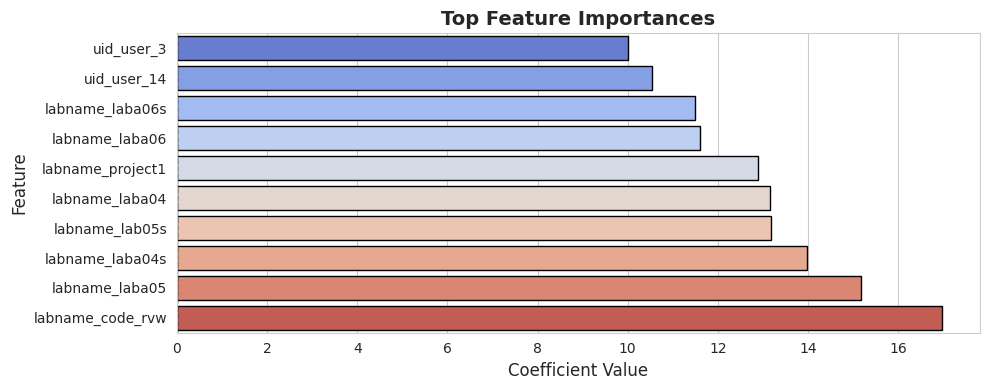

In [83]:
logreg_coefs = np.vstack([estimator.coef_ for estimator in model.estimators_])
logreg_coefs = np.sum(np.abs(logreg_coefs), axis=0)
plot_top_features(logreg_coefs, X.columns, top_n=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [84]:
model = OneVsRestClassifier(SVC(kernel='linear', random_state=21, probability=True))
model.fit(X, y)

,estimator,SVC(kernel='l...ndom_state=21)
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001


In [85]:
accuracy_score(df['dayofweek'], model.predict(X))

0.6126927639383155

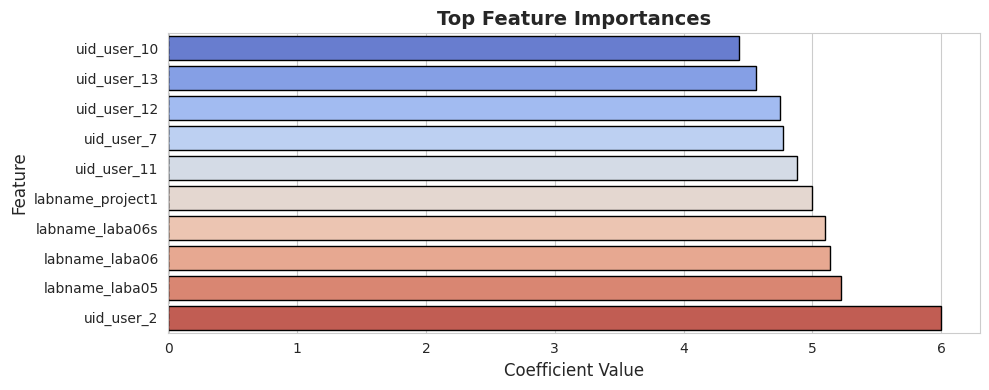

In [86]:
svc_coefs = np.vstack([estimator.coef_ for estimator in model.estimators_])
svc_coefs = np.sum(np.abs(svc_coefs), axis=0)
plot_top_features(svc_coefs, X.columns, top_n=10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [87]:
model = DecisionTreeClassifier(max_depth=4, random_state=21)
model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,21
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [88]:
accuracy_score(df['dayofweek'], model.predict(X))

0.5516014234875445

In [89]:
model_depth3 = DecisionTreeClassifier(max_depth=3, random_state=21)
model_depth3.fit(X, y)
print("depth3:", accuracy_score(df['dayofweek'], model_depth3.predict(X)))

model_depth5 = DecisionTreeClassifier(max_depth=5, random_state=21)
model_depth5.fit(X, y)
print("depth5:", accuracy_score(df['dayofweek'], model_depth5.predict(X)))

depth3: 0.48991696322657174
depth5: 0.6109134045077106


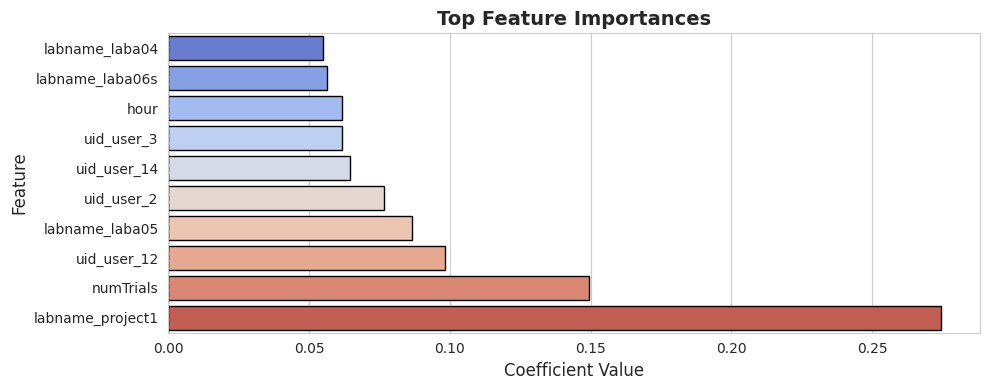

In [90]:
plot_top_features(model.feature_importances_, X.columns, top_n=10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [91]:
model = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
accuracy_score(df['dayofweek'], model.predict(X))

1.0

In [93]:
model_less = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=21)
model_less.fit(X, y)
print("model_less:", accuracy_score(df['dayofweek'], model_less.predict(X)))

model_more = RandomForestClassifier(n_estimators=200, max_depth=50, random_state=21)
model_more.fit(X, y)
print("model_more:", accuracy_score(df['dayofweek'], model_more.predict(X)))

model_less: 0.8701067615658363
model_more: 1.0


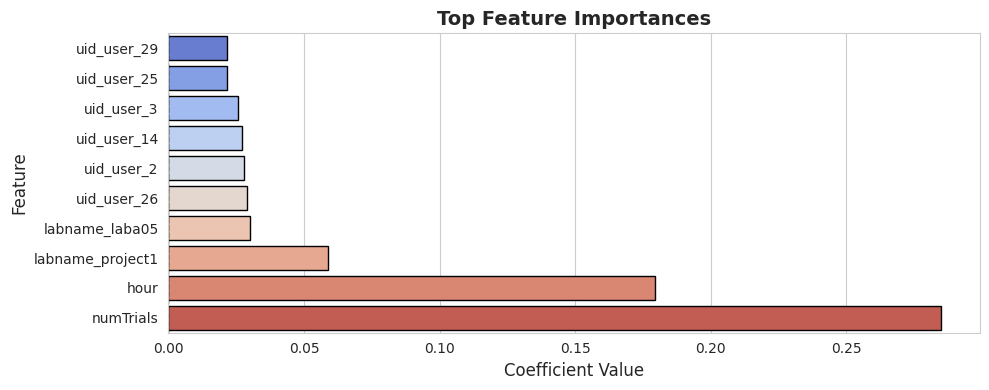

In [94]:
plot_top_features(model.feature_importances_, X.columns, top_n=10)